### Chain Using LangGraph
In this section we will see how we can build a simple chain using Langgraph that uses 4 important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [31]:
from dotenv import load_dotenv
load_dotenv()

import os
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


#### How to use chat messages as our graph state
##### Messages

We can use messages which can be used to capture different roles within a conversation.
LangChain has various message types including HumanMessage, AIMessage, SystemMessage and ToolMessage.
These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call.

Every message have these important components.

- content - content of the message
- name - Specify the name of author
- response_metadata - optionally, a dict of metadata (e.g., often populated by model provider for AIMessages)



In [32]:
from langchain_core.messages import AIMessage,HumanMessage
from pprint import pprint

messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
messages.append(HumanMessage(content=f"I want to learn coding",name="Krish"))
messages.append(AIMessage(content=f"Which programming language you want to learn",name="LLMModel"))
messages.append(HumanMessage(content=f"I want to learn python programming language",name="Krish"))

for message in messages:
    message.pretty_print()



================================== Ai Message ==================================
Name: LLMModel

Please tell me how can I help
================================ Human Message =================================
Name: Krish

I want to learn coding
================================== Ai Message ==================================
Name: LLMModel

Which programming language you want to learn
================================ Human Message =================================
Name: Krish

I want to learn python programming language


### Chat Models

We can use the sequence of message as input with the chatmodels using LLM's and OPENAI.

In [33]:
# from langchain_groq import ChatGroq
# llm=ChatGroq(model="qwen-qwq-32b")
# result=llm.invoke(messages)
from langchain_openai import ChatOpenAI

# Create the OpenAI chat model
llm = ChatOpenAI(model="gpt-4o")  # or "gpt-4-turbo", "gpt-3.5-turbo"

# Invoke with your messages
result = llm.invoke(messages)

In [34]:
result.content

'Great choice! Python is a versatile and beginner-friendly programming language. Here’s a step-by-step plan to help you get started with learning Python:\n\n1. **Set Up Your Environment:**\n   - Download and install Python from the [official website](https://www.python.org/).\n   - Choose an Integrated Development Environment (IDE) or a code editor. Popular choices include PyCharm, VS Code, and Jupyter Notebook.\n\n2. **Learn the Basics:**\n   - **Syntax and Variables:** Understand the basic syntax, how to declare variables, and use data types.\n   - **Operators:** Learn about arithmetic, relational, and logical operators.\n   - **Control Flow:** Study if-else conditions, loops (for and while), and how to control the flow of your program.\n   - **Functions:** Learn to write your own functions, understand parameters, and return values.\n\n3. **Work with Data Structures:**\n   - Lists, tuples, and sets\n   - Dictionaries\n   - Practice manipulating these data structures and understand th

In [35]:
result.response_metadata

{'token_usage': {'completion_tokens': 594,
  'prompt_tokens': 59,
  'total_tokens': 653,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_name': 'gpt-4o-2024-08-06',
 'system_fingerprint': 'fp_689bad8e9a',
 'id': 'chatcmpl-CgkpJpiN2EvJOufKwibvNQdLcrS52',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

### Tools
Tools can be integrated with the LLM models to interact with external systems. External systems can be API's, third party tools.

Whenever a query is asked the model can choose to call the tool and this query is based on the 
natural language input and this will return an output that matches the tool's schema

In [36]:
def add(a:int,b:int)-> int:
    """ Add a and b
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int
    """
    return a+b

In [37]:
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x000001698C8874A0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001698C9A8110>, root_client=<openai.OpenAI object at 0x000001698C886660>, root_async_client=<openai.AsyncOpenAI object at 0x000001698C9A8B30>, model_name='gpt-4o', model_kwargs={}, openai_api_key=SecretStr('**********'))

In [38]:
### Binding tool with llm

llm_with_tools=llm.bind_tools([add])

tool_call=llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Krish")])

In [39]:
llm_with_tools.invoke([HumanMessage(content=f"What is 2 plus 2",name="Krish")])

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_9XjIM9qGXK5iuJBvARjRIA5X', 'function': {'arguments': '{"a":2,"b":2}', 'name': 'add'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 73, 'total_tokens': 90, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_689bad8e9a', 'id': 'chatcmpl-CgkpSPqGQ3TLXI8O2jQ5C3VqjASII', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--49289199-ab95-464f-a278-756859b0edf0-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 2}, 'id': 'call_9XjIM9qGXK5iuJBvARjRIA5X', 'type': 'tool_call'}], usage_metadata={'input_tokens': 73, 'output_tokens': 17, 'total_tokens': 90, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'o

In [40]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'call_ngwqjvJ9omul43MM6u0ExsKZ',
  'type': 'tool_call'}]

### Using messages as state

In [41]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class State(TypedDict):
    message:list[AnyMessage]

#### Reducers
Now, we have a minor problem!

As we discussed, each node will return a new value for our state key messages.

But, this new value will override the prior messages value.

As our graph runs, we want to append messages to our messages state key.

We can use reducer functions to address this.

Reducers allow us to specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should override it as we saw before.

But, to append messages, we can use the pre-built add_messages reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our messages key with the add_messages reducer function as metadata.

In [42]:
from langgraph.graph.message import add_messages
from typing import Annotated
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

### Reducers with add_messages

In [43]:
initial_messages=[AIMessage(content=f"Please tell me how can I help",name="LLMModel")]
initial_messages.append(HumanMessage(content=f"I want to learn coding",name="Krish"))
initial_messages

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel'),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish')]

In [44]:
ai_message=AIMessage(content=f"Which programming language you want to learn",name="LLMModel")
ai_message

AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel')

In [45]:
### Reducers add_messages is to append instead of override
add_messages(initial_messages,ai_message)

[AIMessage(content='Please tell me how can I help', additional_kwargs={}, response_metadata={}, name='LLMModel', id='6d9abd7c-a288-4720-8952-22fb472d2932'),
 HumanMessage(content='I want to learn coding', additional_kwargs={}, response_metadata={}, name='Krish', id='40b3ccc8-8a7a-4aff-98bc-8d6743f84d50'),
 AIMessage(content='Which programming language you want to learn', additional_kwargs={}, response_metadata={}, name='LLMModel', id='43721e4c-c6a0-4d1e-befb-b06213cd18a3')]

In [46]:
## chatbot node functionality
def llm_tool(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

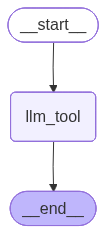

In [47]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
builder=StateGraph(State)

builder.add_node("llm_tool",llm_tool)

builder.add_edge(START,"llm_tool")
builder.add_edge("llm_tool",END)

graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [48]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (call_vGpKqnukVajonNse3sh50WQW)
 Call ID: call_vGpKqnukVajonNse3sh50WQW
  Args:
    a: 2
    b: 2


In [49]:
tools=[add]

In [50]:
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


builder=StateGraph(State)

## Add nodes

builder.add_node("llm_tool",llm_tool)
builder.add_node("tools",ToolNode(tools))

## Add Edge
builder.add_edge(START,"llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)


graph_builder = builder.compile()



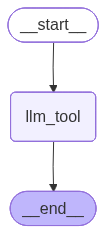

In [51]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [52]:
## invocation

messages=graph.invoke({"messages":"What is 2 plus 2"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add (call_YYaLQd8o2nCRewQkeqEEH0Kn)
 Call ID: call_YYaLQd8o2nCRewQkeqEEH0Kn
  Args:
    a: 2
    b: 2


In [53]:
messages=graph.invoke({"messages":"What Machine Learning"})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What Machine Learning
================================== Ai Message ==================================

It looks like your question is incomplete. Are you asking about what machine learning is, or do you have a specific question related to machine learning? Please provide more details so I can assist you better.
